# Preprocessing et entraînement (Deep Learning - Transformer)
*(Génération de **programmes sportifs**)*

- **Dataset Kaggle** :  
  [600K+ Fitness Exercise & Workout Program Dataset – Kaggle](https://www.kaggle.com/datasets/adnanelouardi/600k-fitness-exercise-and-workout-program-dataset)

## Imports

In [1]:
# Bibliothèques principales
import re
from pathlib import Path
import platform
import random
from pathlib import Path
import json
from datetime import datetime
import warnings
from collections import Counter
import sys
import random
import time
from datetime import timedelta

# Visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import kagglehub
from itables import show

# PyTorch & HuggingFace (version Transformers)
import torch
import torch.nn as nn
from torch.utils.data import  DataLoader
import transformers
import torch.nn as nn
import torch.nn.functional as F

## Configuration

### Configuration GPU

In [2]:
warnings.filterwarnings("ignore")

# --- Infos système ---
print("TrAIn.me — Environnement Windows (PyTorch / Transformers)\n")
print(f"Système      : {platform.system()} {platform.release()}")
print(f"Architecture : {platform.machine()}")

# --- GPU / CPU ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nGPU détecté : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("\nAucun GPU CUDA détecté — utilisation du CPU (plus lent)")

TrAIn.me — Environnement Windows (PyTorch / Transformers)

Système      : Windows 10
Architecture : AMD64

Aucun GPU CUDA détecté — utilisation du CPU (plus lent)


### Configuration graphiques

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

root = Path.cwd()
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("Ajouté au PYTHONPATH :", themes_root)
print("Contenu de", themes_root, ":", [x.name for x in (themes_root).iterdir()])

# Thème personnalisé du projet (uniquement pour les notebooks)
from themes.theme_train_me import set_trainme_theme

# Appliquer le thème graphique TrAIn.me
set_trainme_theme()

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# Thème TrAIn.me (Seaborn/Matplotlib)=
palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
palette_trainme

Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['dataset_fusion', 'eda', 'model_training', 'preprocessing', 'themes', '__init__.py', '__pycache__']


['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Header expérimental

In [4]:
# Reproductibilité complète
SEED_GLOBAL = 42
random.seed(SEED_GLOBAL)
np.random.seed(SEED_GLOBAL)
torch.manual_seed(SEED_GLOBAL)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_GLOBAL)

OUTPUT_MODEL_NAME = "transformer_v3"

# Hyperparamètres modèles
EMBED_DIM = 64
NUM_HEADS = 8
FF_DIM = 512
NUM_BLOCKS = 3
LEARNING_RATE = 1e-4

# Dataset & entraînement
BATCH_SIZE = 16
EPOCHS = 50

MAX_SEQ_LEN = 512

### Affichage des versions d'imports

In [5]:
print("\nVersions utilisées :")
print(f"  - torch        : {torch.__version__}")
print(f"  - transformers : {transformers.__version__}")
print("  - datasets     : installé (HuggingFace Datasets)")
print("\nEnvironnement configuré")


Versions utilisées :
  - torch        : 2.9.1+cpu
  - transformers : 4.57.3
  - datasets     : installé (HuggingFace Datasets)

Environnement configuré


## Chargement et Préparation du Corpus TrAIn.me


### Concaténation du texte

In [6]:
print("Chargement du corpus TrAIn.me (program_summary.csv)...\n")

# Téléchargement automatique du dataset Kaggle
path = kagglehub.dataset_download(
    "adnanelouardi/600k-fitness-exercise-and-workout-program-dataset"
)

print("Dataset téléchargé avec succès !")
print("Chemin local :", path, "\n")

# Conversion du chemin KaggleHub → Path
dataset_dir = Path(path)

# Fichier CSV principal (structure confirmée dans le dataset Kaggle)
csv_path = dataset_dir / "program_summary.csv"

print(f"Lecture du fichier : {csv_path.name}\n")

# Chargement du corpus fusionné
df = pd.read_csv(csv_path)

print("Corpus chargé avec succès !\n")
print("Aperçu du corpus :")
print(df.head())

print("\nInformations générales :")
print(f"  - Nombre total d’entrées : {len(df)}")
print(f"  - Colonnes disponibles    : {list(df.columns)}")

# Sélection des colonnes textuelles à utiliser pour le Transformer
candidate_text_cols = ["text", "program_text", "description", "exercises", "notes"]
text_columns = [c for c in candidate_text_cols if c in df.columns]

if not text_columns:
    # fallback : toutes les colonnes de type "object" (texte)
    text_columns = [c for c in df.columns if df[c].dtype == "object"]

print("\nColonnes textuelles utilisées pour construire le corpus :")
print(f"  - {text_columns}")

# Construction d'une liste de textes à partir des colonnes retenues
corpus_texts = []
for _, row in df[text_columns].iterrows():
    # On concatène les différentes colonnes textuelles ligne par ligne
    parts = [str(v).strip() for v in row.values if isinstance(v, str) and v.strip()]
    if parts:
        corpus_texts.append("\n".join(parts))

print(f"\nNombre de segments textuels retenus : {len(corpus_texts)}")

# Concaténation globale pour le POC Transformer
full_text = "\n\n".join(
    t.strip() for t in corpus_texts
    if t and isinstance(t, str)
)

print("\nRésumé du corpus concaténé :")
print(f"  - Longueur totale (caractères) : {len(full_text)}")
print("  - Aperçu (500 premiers caractères) :\n")
print(full_text[:500])


Chargement du corpus TrAIn.me (program_summary.csv)...

Dataset téléchargé avec succès !
Chemin local : C:\Users\fback\.cache\kagglehub\datasets\adnanelouardi\600k-fitness-exercise-and-workout-program-dataset\versions\1 

Lecture du fichier : program_summary.csv

Corpus chargé avec succès !

Aperçu du corpus :
                                               title                                        description  \
0  (MASS MONSTER) High Intensity 4 Day Upper Lowe...  Build tones of muscular with this high intensi...   
1                         (NOT MY PROGRAM)SHJ Jotaro                            Build strength and size   
2  1 PowerLift Per Day Powerbuilding 5 Day Bro Split  Based off of Andy Baker's KCS (Kingwood Streng...   
3                      10 Week Mass Building Program  This workout is designed to increase your musc...   
4                             10 week deadlift focus                                  Increase deadlift   

                                    level    

### Vérifications du corpus

In [7]:
print("\nVérifications du corpus Transformer TrAIn.me\n")

# Taille brute du texte
print(f"Longueur totale du corpus (caractères) : {len(full_text)}")

# Quelques statistiques simples
nb_lignes = full_text.count("\n")
nb_mots = len(full_text.split())

print(f"Nombre approximatif de lignes : {nb_lignes}")
print(f"Nombre approximatif de mots   : {nb_mots}")

# Aperçu du contenu
print("\n--- Exemple brut du corpus (300 premiers caractères) ---\n")
print(full_text[:300])

# Vérification de segments aléatoires
print("\n--- Exemples aléatoires du corpus ---\n")
for i in range(3):
    idx = random.randint(0, len(corpus_texts) - 1)
    extrait = corpus_texts[idx][:200].replace("\n", " ")
    print(f"[{i+1}] {extrait}...")


Vérifications du corpus Transformer TrAIn.me

Longueur totale du corpus (caractères) : 777003
Nombre approximatif de lignes : 13033
Nombre approximatif de mots   : 130585

--- Exemple brut du corpus (300 premiers caractères) ---

Build tones of muscular with this high intensity 4 day upper lower workout routine.

Weekly Setup:
Day 1 - Upper Push Focus
Day 2 - Lower Quad Focus
Day 3 - Rest/Active Recovery
Day 4 - Upper Pull Focus
Day 5 - Rest/Active Recovery
Day 6 - Lower Hamstring Focus
Day 7 - Rest/Active Recovery 

Muscle 

--- Exemples aléatoires du corpus ---

[1] Beginner friendly simple...
[2] Overload Overload is critical to the muscle building process. Push each set for the maximum number of reps, stopping that set either when you feel your form is slipping, or if you feel like you may fa...
[3] To push you to the limits and not hold back one bit...


### Prétraitement du texte

In [8]:
def clean_text(texte):
    """Nettoie et normalise le texte pour un Transformer word-level."""
    texte = texte.lower()

    # Ajouter des espaces autour de la ponctuation utile
    # (évite la fusion de tokens du type "fatigué!continue")
    texte = re.sub(r"([.,!?])", r" \1 ", texte)

    # Réduire les espaces multiples
    texte = re.sub(r"\s+", " ", texte)

    return texte.strip()


# Nettoyage du corpus Transformer (basé sur corpus_texts)
cleaned_corpus = [clean_text(phrase) for phrase in corpus_texts]

print("Exemples de phrases nettoyées :")
for i in range(3):
    print("\nLongueur avant nettoyage :", len(corpus_texts[i]))
    print(f"Original : {corpus_texts[i]}")
    print("Longueur après nettoyage :", len(cleaned_corpus[i]))
    print(f"Nettoyé  : {cleaned_corpus[i]}")


Exemples de phrases nettoyées :

Longueur avant nettoyage : 449
Original : Build tones of muscular with this high intensity 4 day upper lower workout routine.

Weekly Setup:
Day 1 - Upper Push Focus
Day 2 - Lower Quad Focus
Day 3 - Rest/Active Recovery
Day 4 - Upper Pull Focus
Day 5 - Rest/Active Recovery
Day 6 - Lower Hamstring Focus
Day 7 - Rest/Active Recovery 

Muscle Groups |Sets Per Week
Back - 10
Shoulders - 10
Chest - 9
Quads - 9
Hamstrings - 9
Glutes - 9
Biceps - 7
Triceps - 7
Lower Back - 4
Calves - 4
Abs - 4
Longueur après nettoyage : 447
Nettoyé  : build tones of muscular with this high intensity 4 day upper lower workout routine . weekly setup: day 1 - upper push focus day 2 - lower quad focus day 3 - rest/active recovery day 4 - upper pull focus day 5 - rest/active recovery day 6 - lower hamstring focus day 7 - rest/active recovery muscle groups |sets per week back - 10 shoulders - 10 chest - 9 quads - 9 hamstrings - 9 glutes - 9 biceps - 7 triceps - 7 lower back - 4 calv

### Tokenization

In [9]:
print("Construction du tokenizer (word-level minimal)…\n")

# Tokenisation simple : split sur les espaces après nettoyage
tokenized_sentences = [sentence.split() for sentence in cleaned_corpus]

# Compter les fréquences
word_counter = Counter()
for sent in tokenized_sentences:
    word_counter.update(sent)

# Définition des tokens spéciaux
special_tokens = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

# Construire le vocabulaire (tokens spéciaux en premier)
vocab = special_tokens + sorted(word_counter.keys())

# Dictionnaire mot --> id
word2idx = {word: idx for idx, word in enumerate(vocab)}

# Dictionnaire inverse id →--> mot
idx2word = {idx: word for word, idx in word2idx.items()}

# Taille du vocabulaire
vocab_size = len(vocab)
print(f"Taille du vocabulaire : {vocab_size} mots\n")

# Top 20 mots les plus fréquents
print("Top 20 mots les plus fréquents :\n")
for i, (word, freq) in enumerate(word_counter.most_common(20), 1):
    print(f"{i:2d}. '{word}' : {freq} fois")

Construction du tokenizer (word-level minimal)…

Taille du vocabulaire : 11133 mots

Top 20 mots les plus fréquents :

 1. '.' : 7435 fois
 2. ',' : 5851 fois
 3. 'the' : 4194 fois
 4. 'and' : 4017 fois
 5. 'to' : 3900 fois
 6. 'a' : 2702 fois
 7. 'for' : 2214 fois
 8. 'you' : 2006 fois
 9. 'of' : 1884 fois
10. 'is' : 1681 fois
11. 'program' : 1603 fois
12. 'this' : 1443 fois
13. 'on' : 1395 fois
14. 'with' : 1293 fois
15. 'in' : 1235 fois
16. 'week' : 1193 fois
17. 'strength' : 1020 fois
18. 'your' : 998 fois
19. 'muscle' : 797 fois
20. 'day' : 787 fois


### Préparation des séquences d’entraînement

In [10]:
def prepare_sequences(textes, word2idx, max_seq_len=None):
    """
    Crée des séquences input-output (n-grams progressifs) à partir
    d'un tokenizer word-level dictionnaire {mot → id}.
    """
    sequences = []

    for texte in textes:
        tokens = [word2idx.get(tok, word2idx["<UNK>"]) for tok in texte.split()]

        # Ignore les phrases trop courtes
        if len(tokens) <= 1:
            continue

        # Génération des n-grams progressifs
        for i in range(1, len(tokens)):
            n_gram = tokens[:i+1]

            # Tronquage éventuel
            if max_seq_len is not None and len(n_gram) > max_seq_len:
                n_gram = n_gram[-max_seq_len:]

            sequences.append(n_gram)

    return sequences


# Création des séquences Transformer
sequences = prepare_sequences(
    cleaned_corpus,
    word2idx,
    max_seq_len=MAX_SEQ_LEN  # None si tu veux laisser les longueurs croissantes
)

print(f"\nNombre total de séquences : {len(sequences)}")
print(f"\nExemples de séquences (premiers tokens) :")


# Exemple sur la première phrase
example_sentence = cleaned_corpus[0]
example_tokens = [word2idx.get(tok, word2idx["<UNK>"]) for tok in example_sentence.split()]

print(f"\nPhrase : '{example_sentence}'")
print(f"Tokens : {example_tokens}\n")

# Affichage des 5 premiers n-grams générés
for i in range(1, min(6, len(example_tokens))):
    seq = example_tokens[:i+1]
    words_seq = [idx2word[idx] for idx in seq]

    print(f"  {seq[:-1]} → {seq[-1]} | {words_seq[:-1]} → {words_seq[-1]}")



Nombre total de séquences : 141997

Exemples de séquences (premiers tokens) :

Phrase : 'build tones of muscular with this high intensity 4 day upper lower workout routine . weekly setup: day 1 - upper push focus day 2 - lower quad focus day 3 - rest/active recovery day 4 - upper pull focus day 5 - rest/active recovery day 6 - lower hamstring focus day 7 - rest/active recovery muscle groups |sets per week back - 10 shoulders - 10 chest - 9 quads - 9 hamstrings - 9 glutes - 9 biceps - 7 triceps - 7 lower back - 4 calves - 4 abs - 4'
Tokens : [2688, 10018, 7145, 6886, 10770, 9887, 5275, 5679, 1241, 3490, 10338, 6326, 10812, 8569, 784, 10652, 8885, 3490, 805, 695, 10338, 8039, 4635, 3490, 1032, 695, 6326, 8071, 4635, 3490, 1145, 695, 8445, 8250, 3490, 1241, 695, 10338, 7981, 4635, 3490, 1316, 695, 8445, 8250, 3490, 1414, 695, 6326, 5149, 4635, 3490, 1479, 695, 8445, 8250, 6873, 5055, 10947, 7455, 10628, 2227, 695, 843, 8963, 695, 843, 2946, 695, 1563, 8073, 695, 1563, 5150, 695, 1563, 49

### Padding et préparation des tenseurs PyTorch

Longueur maximale détectée : 512

Dimensions des données :
  X (input)  : torch.Size([141997, 511])  # (nombre_sequences, longueur_sequence-1)
  y (output) : torch.Size([141997])  # (nombre_sequences,) indices de classes

  Longueur maximale de séquence (avec padding) : 512


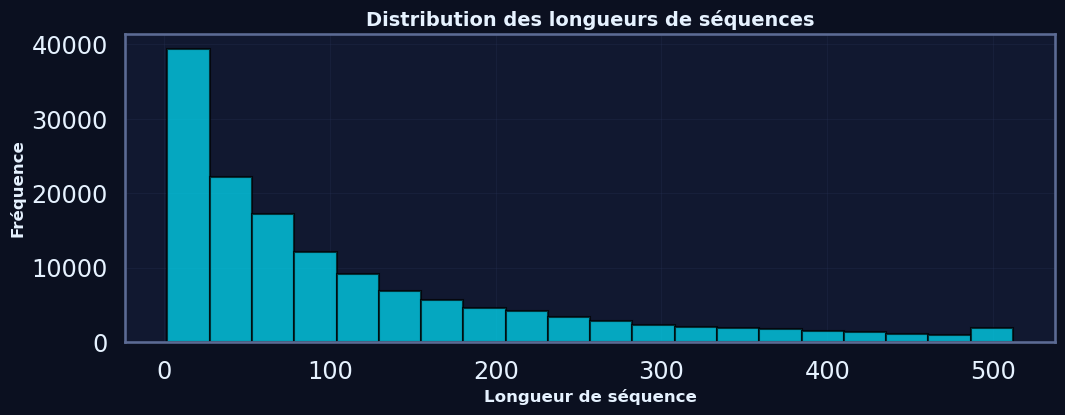

In [11]:
# Longueur maximale des séquences (en nombre de tokens)
max_sequence_length = max(len(seq) for seq in sequences)

print(f"Longueur maximale détectée : {max_sequence_length}")

# Padding manuel en préfixant avec le token <PAD> (id = 0)
PAD_IDX = word2idx["<PAD>"]

padded_sequences = []
for seq in sequences:
    if len(seq) < max_sequence_length:
        pad_len = max_sequence_length - len(seq)
        padded = [PAD_IDX] * pad_len + seq
    else:
        # Par sécurité, on tronque si jamais une séquence dépasse (cas futur)
        padded = seq[-max_sequence_length:]
    padded_sequences.append(padded)

padded_sequences = torch.tensor(padded_sequences, dtype=torch.long)

# Séparation X (input) et y (output)
X = padded_sequences[:, :-1]  # Tous les tokens sauf le dernier
y = padded_sequences[:, -1]   # Le dernier token (classe cible, entiers)

print(f"\nDimensions des données :")
print(f"  X (input)  : {X.shape}  # (nombre_sequences, longueur_sequence-1)")
print(f"  y (output) : {y.shape}  # (nombre_sequences,) indices de classes")
print(f"\n  Longueur maximale de séquence (avec padding) : {max_sequence_length}")

# Visualisation de la distribution des longueurs (hors padding)
sequence_lengths = (padded_sequences != PAD_IDX).sum(dim=1).tolist()

plt.figure(figsize=(12, 4))
plt.hist(sequence_lengths, bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Longueur de séquence", fontsize=12, fontweight="bold")
plt.ylabel("Fréquence", fontsize=12, fontweight="bold")
plt.title("Distribution des longueurs de séquences", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.show()

### Construction du dataset séquentiel


In [12]:
# Conversion vers torch.Tensor
X_tensor = torch.tensor(X, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.long)

# Calcul des tailles
dataset_size = len(X_tensor)
val_size = int(dataset_size * 0.1)   # 10% validation
train_size = dataset_size - val_size

# Split aléatoire reproductible
generator = torch.Generator().manual_seed(SEED_GLOBAL)

# Construction du dataset (liste de tuples)
full_dataset = list(zip(X_tensor, y_tensor))

# Split train/val
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset,
    lengths=[train_size, val_size],
    generator=generator
)

print("Split effectué (PyTorch)")
print("  - train dataset :", len(train_dataset))
print("  - val dataset   :", len(val_dataset))


Split effectué (PyTorch)
  - train dataset : 127798
  - val dataset   : 14199


## Architecture Transformer


### Implémentation des composants

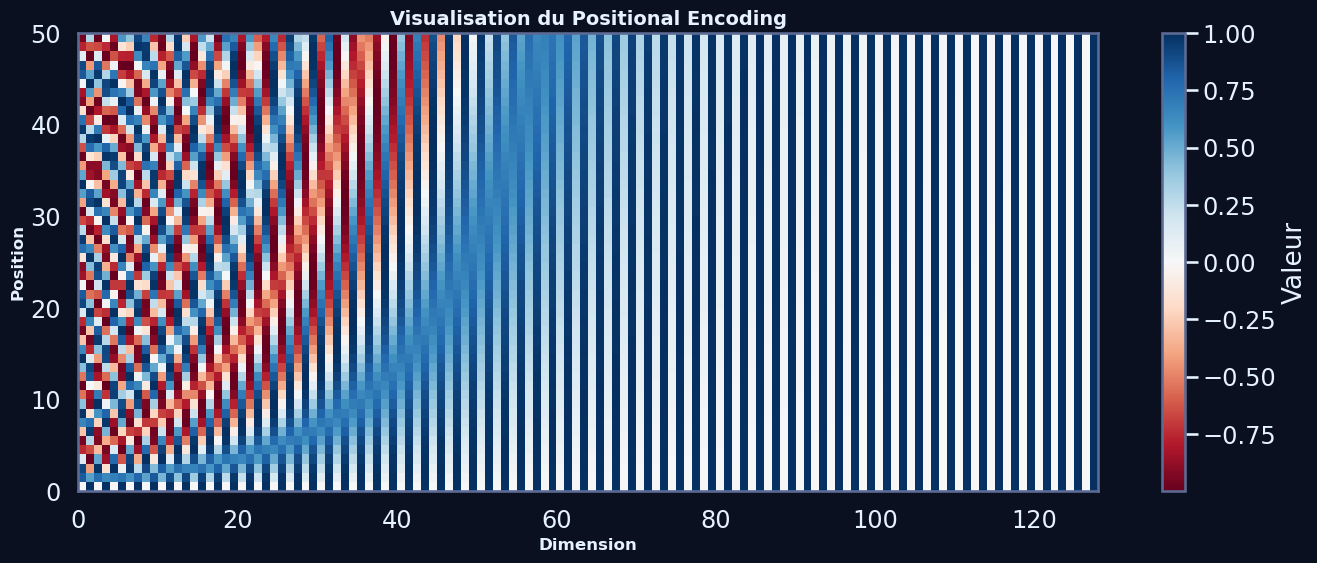


Le positional encoding ajoute une information unique à chaque position.
   Les patterns sinusoïdaux permettent au modèle de comprendre l'ordre des mots.


In [13]:
def get_positional_encoding(seq_len, d_model):
    """
    Crée le positional encoding pour le Transformer.
    Utilise des fonctions sinusoïdales pour encoder la position.
    Version 100% PyTorch (sans TensorFlow).
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    positions = torch.arange(seq_len, dtype=torch.float32, device=device).unsqueeze(1)
    dimensions = torch.arange(d_model, dtype=torch.float32, device=device).unsqueeze(0)

    angle_rates = 1 / torch.pow(10000, (2 * (dimensions // 2)) / d_model)
    angle_rads = positions * angle_rates

    # Sin sur les dimensions paires — Cos sur les dimensions impaires
    pos_encoding = torch.zeros((seq_len, d_model), device=device)
    pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

    # On ajoute une dimension batch fictive : (1, seq_len, d_model)
    return pos_encoding.unsqueeze(0)


# Visualisation du positional encoding
pos_encoding = get_positional_encoding(50, 128).cpu().numpy()

plt.figure(figsize=(14, 6))
plt.pcolormesh(pos_encoding[0], cmap='RdBu')
plt.xlabel('Dimension', fontsize=12, fontweight='bold')
plt.ylabel('Position', fontsize=12, fontweight='bold')
plt.colorbar(label='Valeur')
plt.title('Visualisation du Positional Encoding', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLe positional encoding ajoute une information unique à chaque position.")
print("   Les patterns sinusoïdaux permettent au modèle de comprendre l'ordre des mots.")


### MultiHeadSelfAttention

In [14]:
class MultiHeadSelfAttention(nn.Module):
    """
    Implémentation du Multi-Head Self-Attention en PyTorch.
    
    Cette couche est le cœur du Transformer. Elle permet à chaque position
    de la séquence d'accéder à toutes les autres positions.
    """
    def __init__(self, embed_dim: int, num_heads: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        assert embed_dim % num_heads == 0, "embed_dim doit être divisible par num_heads"

        self.head_dim = embed_dim // num_heads

        # Projections linéaires pour Q, K, V
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key   = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

        # Projection finale
        self.out = nn.Linear(embed_dim, embed_dim)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Sépare la dimension embed_dim en (num_heads, head_dim)
        et transpose en (batch, num_heads, seq_len, head_dim).
        """
        batch_size, seq_len, _ = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        return x.permute(0, 2, 1, 3)  # (batch, num_heads, seq_len, head_dim)

    def _scaled_dot_product_attention(
        self,
        q: torch.Tensor,
        k: torch.Tensor,
        v: torch.Tensor,
        causal: bool = True,
    ):
        """
        Attention scaled dot-product avec option de masque de causalité.
        q, k, v : (batch, num_heads, seq_len, head_dim)
        """
        # (batch, num_heads, seq_len, seq_len)
        scores = torch.matmul(q, k.transpose(-2, -1))
        dim_k = k.size(-1)
        scores = scores / (dim_k ** 0.5)

        if causal:
            seq_len = scores.size(-1)
            # Matrice upper-triangular (au-dessus de la diagonale) → positions futures
            mask = torch.triu(
                torch.ones(seq_len, seq_len, device=scores.device, dtype=torch.bool),
                diagonal=1
            )
            scores = scores.masked_fill(mask, float("-inf"))

        attn_weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(attn_weights, v)  # (batch, num_heads, seq_len, head_dim)

        return attn_output, attn_weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (batch, seq_len, embed_dim)
        """
        batch_size, seq_len, _ = x.size()

        # Projections linéaires
        q = self.query(x)  # (batch, seq_len, embed_dim)
        k = self.key(x)
        v = self.value(x)

        # Multi-head : (batch, num_heads, seq_len, head_dim)
        q = self._split_heads(q)
        k = self._split_heads(k)
        v = self._split_heads(v)

        # Attention avec masque de causalité
        attn_output, _ = self._scaled_dot_product_attention(q, k, v, causal=True)

        # Recombiner les heads
        attn_output = attn_output.permute(0, 2, 1, 3).contiguous()  # (batch, seq_len, num_heads, head_dim)
        attn_output = attn_output.view(batch_size, seq_len, self.embed_dim)  # (batch, seq_len, embed_dim)

        # Projection finale
        output = self.out(attn_output)
        return output

print("Classe MultiHeadSelfAttention définie (PyTorch, masque de causalité intégré) ✓")


Classe MultiHeadSelfAttention définie (PyTorch, masque de causalité intégré) ✓


### TransformerBlock

In [15]:
class TransformerBlock(nn.Module):
    """
    Un bloc Transformer complet (version PyTorch).

    Combine :
    - Multi-Head Self-Attention
    - Feed-Forward Network
    - Layer Normalization
    - Residual Connections
    - Dropout
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()

        # Attention multi-têtes
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)

        # Feed-Forward Network : Dense → ReLU → Dense
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )

        # Layer Normalization
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)

        # Dropout
        self.dropout_att = nn.Dropout(dropout_rate)
        self.dropout_ffn = nn.Dropout(dropout_rate)

    def forward(self, x):
        # Multi-Head Attention + residual + normalization
        attn_output = self.att(x)
        attn_output = self.dropout_att(attn_output)
        out1 = self.layernorm1(x + attn_output)

        # Feed-Forward + residual + normalization
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout_ffn(ffn_output)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2


print("Classe TransformerBlock définie (PyTorch)")

Classe TransformerBlock définie (PyTorch)


### PositionalEmbedding

In [16]:
class PositionalEmbedding(nn.Module):
    """
    Combine l'embedding des tokens avec le positional encoding sinusoïdal.
    """
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = get_positional_encoding(max_len, embed_dim)  # (1, max_len, embed_dim)

    def forward(self, x):
        """
        x : (batch, seq_len)
        sortie : (batch, seq_len, embed_dim)
        """
        seq_len = x.size(1)

        # Embedding des tokens
        token_embeddings = self.token_emb(x)  # (batch, seq_len, embed_dim)

        # Ajouter le positional encoding (tronqué à seq_len)
        x = token_embeddings + self.pos_encoding[:, :seq_len, :]

        return x


print("Classe PositionalEmbedding définie (PyTorch)")

Classe PositionalEmbedding définie (PyTorch)


## Construction du modèle Transformer

### Classe de création du modèle

In [17]:
class TransformerLanguageModel(nn.Module):
    """
    Modèle Transformer minimal pour la génération de texte.

    Architecture :
    Input → PositionalEmbedding → [TransformerBlock] × N → Dernière position → Linear (vocab_size)
    """
    def __init__(
        self,
        vocab_size: int,
        max_length: int,
        embed_dim: int = 128,
        num_heads: int = 4,
        ff_dim: int = 128,
        num_blocks: int = 2,
        dropout_rate: float = 0.1,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.embed_dim = embed_dim

        # Embedding + positional encoding
        self.embedding = PositionalEmbedding(vocab_size, embed_dim, max_length)

        # Pile de blocs Transformer
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    ff_dim=ff_dim,
                    dropout_rate=dropout_rate,
                )
                for _ in range(num_blocks)
            ]
        )

        # Dropout + couche de sortie (logits sur le vocabulaire)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (batch_size, seq_len) — séquence de tokens (ids)
        Retour :
            logits : (batch_size, vocab_size) pour le prochain token
        """
        # Embedding + positional encoding
        x = self.embedding(x)  # (batch, seq_len, embed_dim)

        # Passage dans la pile de blocs Transformer
        for block in self.blocks:
            x = block(x)  # (batch, seq_len, embed_dim)

        # On ne garde que la dernière position pour la prédiction du prochain mot
        x = x[:, -1, :]  # (batch, embed_dim)

        x = self.dropout(x)
        logits = self.fc_out(x)  # (batch, vocab_size)

        # Pas de softmax ici : on utilisera CrossEntropyLoss sur les logits
        return logits


def create_transformer_model(
    vocab_size: int,
    max_length: int,
    embed_dim: int = 128,
    num_heads: int = 4,
    ff_dim: int = 128,
    num_blocks: int = 2,
    dropout_rate: float = 0.1,
) -> TransformerLanguageModel:
    """
    Crée un modèle Transformer pour la génération de texte (version PyTorch).

    Architecture :
    Input --> PositionalEmbedding --> [TransformerBlock] × N --> Dernière position --> Linear --> logits
    """
    model = TransformerLanguageModel(
        vocab_size=vocab_size,
        max_length=max_length,
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        num_blocks=num_blocks,
        dropout_rate=dropout_rate,
    )

    # Petit résumé textuel
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(model)
    print(f"\nNombre de paramètres entraînables : {total_params:,}")

    return model

In [18]:
create_transformer_model

<function __main__.create_transformer_model(vocab_size: int, max_length: int, embed_dim: int = 128, num_heads: int = 4, ff_dim: int = 128, num_blocks: int = 2, dropout_rate: float = 0.1) -> __main__.TransformerLanguageModel>

### Création du modèle

In [19]:
# Création du modèle Transformer
transformer_model = create_transformer_model(
    vocab_size=vocab_size,
    max_length=max_sequence_length,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_blocks=NUM_BLOCKS
)

print("\nModèle Transformer créé !\n")

# Optimizer PyTorch (learning rate plus bas : essentiel pour la stabilité)
optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=LEARNING_RATE
)

# Loss pour la prédiction du prochain token (logits → CrossEntropyLoss)
criterion = torch.nn.CrossEntropyLoss()

# Informations générales sur le modèle
print(transformer_model)

total_params = sum(p.numel() for p in transformer_model.parameters())
trainable_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)

print(f"\nNombre total de paramètres         : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")
print(f"Nombre de paramètres figés        : {total_params - trainable_params:,}")

print("\nLe modèle est prêt pour l'entraînement !")


TransformerLanguageModel(
  (embedding): PositionalEmbedding(
    (token_emb): Embedding(11133, 64)
  )
  (blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (att): MultiHeadSelfAttention(
        (query): Linear(in_features=64, out_features=64, bias=True)
        (key): Linear(in_features=64, out_features=64, bias=True)
        (value): Linear(in_features=64, out_features=64, bias=True)
        (out): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=64, bias=True)
      )
      (layernorm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (layernorm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout_att): Dropout(p=0.1, inplace=False)
      (dropout_ffn): Dropout(p=0.1, inplace=False)
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc_out): Linear(in_features=64, out_fea

## Callbacks

#### Callback Early Stopping pour éviter l’overfitting

In [20]:
class EarlyStopping:
    """
    Early Stopping maison pour PyTorch.
    Fonctionne comme keras.callbacks.EarlyStopping.
    
    - monitor : 'val_loss'
    - patience : nombre d'epochs sans amélioration
    - restore_best_weights : si True, recharge les meilleurs poids
    """
    def __init__(self, patience=5, restore_best_weights=True):
        self.patience = patience
        self.restore_best_weights = restore_best_weights

        self.best_loss = float("inf")
        self.best_state_dict = None
        self.wait = 0
        self.stopped = False

    def step(self, val_loss, model):
        """
        À appeler à chaque epoch avec la val_loss.
        Retourne True si entraînement doit s'arrêter.
        """
        if val_loss < self.best_loss:
            # Amélioration observée
            self.best_loss = val_loss
            self.wait = 0
            
            if self.restore_best_weights:
                # Sauvegarde d'un snapshot des meilleurs poids
                self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            # Pas d'amélioration
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped = True
                print(f"\nEarlyStopping: arrêt après {self.patience} epochs sans amélioration.")
                
                if self.restore_best_weights and self.best_state_dict is not None:
                    print("Restauration des meilleurs poids...")
                    model.load_state_dict(self.best_state_dict)

                return True  # stop training

        return False


# Instanciation (équivalent Keras)
early_stopping = EarlyStopping(
    patience=50,          # 50 epochs sans amélioration → stop
    restore_best_weights=True
)

print("Callback EarlyStopping (PyTorch) initialisé")

Callback EarlyStopping (PyTorch) initialisé


#### Checkpoint pour sauvegarder le meilleur modèle

In [ ]:
# Définition du chemin de sauvegarde (format PyTorch .pt)
checkpoint_path = project_root / "models" / f"{OUTPUT_MODEL_NAME}.pt"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint path : {checkpoint_path}")

class ModelCheckpoint:
    """
    Sauvegarde automatique du meilleur modèle (équivalent Keras).
    """
    def __init__(self, filepath, verbose=True):
        self.filepath = filepath
        self.best_loss = float("inf")
        self.verbose = verbose

    def step(self, val_loss, model):
        """Sauvegarde si amélioration."""
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.filepath)
            if self.verbose:
                print(f"Nouveau meilleur modèle sauvegardé (val_loss={val_loss:.4f})")

# Instanciation du checkpoint
checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path),
    verbose=True
)

Checkpoint path : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\models\transformer_v3.pt


#### Callback pour visualiser la progression


In [22]:
class TransformerProgressCallback:
    """
    Callback maison pour suivre et visualiser la progression d'entraînement
    (équivalent du Callback Keras).
    """
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
    
    def log(self, train_loss, val_loss):
        """
        Appelé à chaque epoch depuis la boucle d'entraînement PyTorch.
        """
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        
        clear_output(wait=True)

        # --- Visualisation ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

        # Courbe Loss Train
        ax1.plot(self.train_losses, color='orange', linewidth=2, marker='o', markersize=4)
        ax1.set_title('Train Loss (Transformer)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Epoch', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.grid(alpha=0.3)

        # Courbe Loss Val
        ax2.plot(self.val_losses, color='purple', linewidth=2, marker='o', markersize=4)
        ax2.set_title('Validation Loss (Transformer)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Epoch', fontsize=12)
        ax2.set_ylabel('Loss', fontsize=12)
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"Epoch {len(self.train_losses)}")
        print(f"  > Train Loss : {train_loss:.4f}")
        print(f"  > Val   Loss : {val_loss:.4f}")


# Instanciation du callback
progress_callback_transformer = TransformerProgressCallback()

print("Callback TransformerProgressCallback initialisé")

Callback TransformerProgressCallback initialisé


### Entraînement du modèle

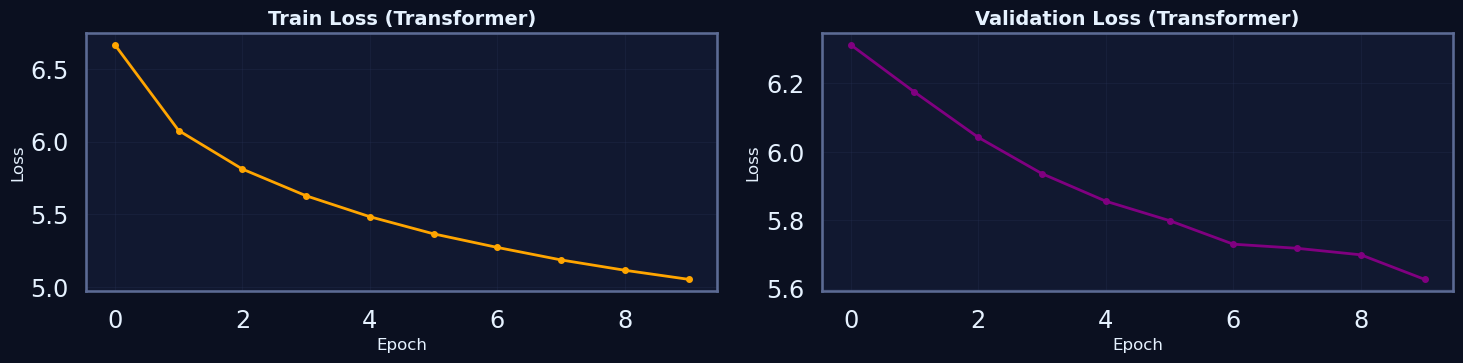

Epoch 10
  > Train Loss : 5.0544
  > Val   Loss : 5.6273
📦 Nouveau meilleur modèle sauvegardé (val_loss=5.6273)

RÉCAP ÉPOCH
--------------------------------------------------------------------------------
   Train Loss : 5.0544
   Val   Loss : 5.6273
   Durée     : 1:11:16
--------------------------------------------------------------------------------

ÉPOCH 11/50

Phase TRAIN
   → 7988 batches...

     Batch  798/7988 | Loss: 4.8167
     Batch 1596/7988 | Loss: 5.2643
     Batch 2394/7988 | Loss: 5.7088
     Batch 3192/7988 | Loss: 5.3728
     Batch 3990/7988 | Loss: 5.2077
     Batch 4788/7988 | Loss: 3.7118
     Batch 5586/7988 | Loss: 4.2827
     Batch 6384/7988 | Loss: 4.3016


In [ ]:
print("Début de l'entraînement du modèle Transformer...\n")
print("/!\\  Note : le Transformer nécessite souvent plus d'epochs que le LSTM")
print("     pour converger, surtout avec un learning rate faible.\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer_model = transformer_model.to(device)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

history_transformer = {"train_loss": [], "val_loss": []}

# Timer global
start_training = time.time()

for epoch in range(1, EPOCHS + 1):

    print("\n" + "="*80)
    print(f"ÉPOCH {epoch}/{EPOCHS}")
    print("="*80)

    epoch_start_time = time.time()

    # --------- Phase Train ---------
    transformer_model.train()
    running_train_loss = 0.0
    total_train_batches = len(train_loader)

    print("\nPhase TRAIN")
    print(f"   → {total_train_batches} batches...\n")

    for batch_idx, (batch_X, batch_y) in enumerate(train_loader, start=1):
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = transformer_model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        if batch_idx % max(1, (total_train_batches // 10)) == 0:
            print(f"     Batch {batch_idx:4d}/{total_train_batches} "
                  f"| Loss: {loss.item():.4f}")

    epoch_train_loss = running_train_loss / total_train_batches

    # Phase Validation
    transformer_model.eval()
    running_val_loss = 0.0
    total_val_batches = len(val_loader)

    print("\nPhase VALIDATION")
    print(f"   → {total_val_batches} batches...\n")

    with torch.no_grad():
        for batch_idx, (batch_X, batch_y) in enumerate(val_loader, start=1):
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = transformer_model(batch_X)
            loss = criterion(logits, batch_y)

            running_val_loss += loss.item()

            if batch_idx % max(1, (total_val_batches // 5)) == 0:
                print(f"     Batch {batch_idx:4d}/{total_val_batches} "
                      f"| Loss: {loss.item():.4f}")

    epoch_val_loss = running_val_loss / total_val_batches

    # Stockage
    history_transformer["train_loss"].append(epoch_train_loss)
    history_transformer["val_loss"].append(epoch_val_loss)

    # Callbacks
    if progress_callback_transformer is not None:
        progress_callback_transformer.log(epoch_train_loss, epoch_val_loss)

    if checkpoint is not None:
        checkpoint.step(epoch_val_loss, transformer_model)

    stop = False
    if early_stopping is not None:
        stop = early_stopping.step(epoch_val_loss, transformer_model)

    # Logs récapitulatifs
    epoch_duration = timedelta(seconds=int(time.time() - epoch_start_time))

    print("\nRÉCAP ÉPOCH")
    print("-"*80)
    print(f"   Train Loss : {epoch_train_loss:.4f}")
    print(f"   Val   Loss : {epoch_val_loss:.4f}")
    print(f"   Durée     : {epoch_duration}")
    print("-"*80)

    if stop:
        print("\nEntraînement interrompu par EarlyStopping.")
        break

# Temps global
total_time = timedelta(seconds=int(time.time() - start_training))
print("\nEntraînement Transformer terminé !")
print(f"Temps total : {total_time}")
print("\nNote : si le Transformer n'a pas convergé suffisamment, "
      "augmentez le nombre d'epochs (par ex. 200–300).")


### Perplexité

In [ ]:
# Récupérer la dernière loss de validation
final_loss = history_transformer["val_loss"][-1]

# Calcul de la perplexité
perplexity = np.exp(final_loss)

print(f"Perplexité approx : {perplexity:.2f}")


## Test de génération de texte avec le Transformer

In [ ]:
def generate_text(model, word2idx, idx2word, seed_text, num_words=10, temperature=1.0, seed=None):
    """
    Génère du texte auto-régressivement avec le Transformer PyTorch.

    - model        : modèle Transformer PyTorch
    - word2idx     : dict mot → id
    - idx2word     : dict id → mot
    - seed_text    : texte de départ (str)
    - num_words    : nombre de mots à générer
    - temperature  : contrôle la créativité (0.5=conservateur, 1.0=normal, 2.0=créatif)
    """
    model.eval()

    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random

    generated_text = seed_text

    # On récupère l'index du token PAD pour éventuellement le pénaliser
    pad_idx = word2idx.get("<PAD>", None)

    for _ in range(num_words):

        # --- Tokenisation simple (split word-level) ---
        tokens = [word2idx.get(w, word2idx["<UNK>"])
                  for w in generated_text.lower().split()]

        # Padding à gauche comme dans l’entraînement
        tokens_padded = tokens[-(max_sequence_length - 1):]
        pad_len = (max_sequence_length - 1) - len(tokens_padded)
        tokens_input = [word2idx["<PAD>"]] * pad_len + tokens_padded

        x = torch.tensor(tokens_input, dtype=torch.long).unsqueeze(0).to(device)

        # Prédiction du prochain mot
        with torch.no_grad():
            logits = model(x)              # (1, vocab_size)
            logits = logits[0].cpu().numpy()  # → (vocab_size,)

        # On peut éviter de prédire PAD en le pénalisant fortement
        if pad_idx is not None and 0 <= pad_idx < logits.shape[0]:
            logits[pad_idx] = -1e9

        # Application de la température sur les LOGITS (pas un log de proba)
        logits = logits / max(temperature, 1e-6)

        # Softmax stable numériquement
        logits = logits - np.max(logits)      # pour éviter overflow exp
        exp_logits = np.exp(logits)
        sum_exp = np.sum(exp_logits)

        if not np.isfinite(sum_exp) or sum_exp == 0:
            # fallback de sécurité : distribution uniforme
            probs = np.ones_like(exp_logits) / len(exp_logits)
        else:
            probs = exp_logits / sum_exp

        # Choix du token
        predicted_id = rng.choice(len(probs), p=probs)

        # Convertir ID → mot
        predicted_word = idx2word.get(predicted_id, "<UNK>")

        generated_text += " " + predicted_word

    return generated_text


#  TESTS DE GÉNÉRATION
print("Génération de texte avec Transformer PyTorch\n")
print("=" * 80)

test_seeds = [
    "lose fat and gain muscle",
    "3 workout sessions per week",
    "I sprained my right ankle",
    "background in judo and tennis",
    "getting back into training at a gym"
]


for i, seed in enumerate(test_seeds):
    generated = generate_text(
        model=transformer_model,
        word2idx=word2idx,
        idx2word=idx2word,
        seed_text=seed,
        num_words=8,
        temperature=0.8,
        seed=SEED_GLOBAL + i
    )

    print(f"\nSeed: '{seed}'")
    print(f"> Généré: {generated}")
    print("-" * 80)

## Génération de texte
### Tests qualitatifs

In [ ]:
# Comparaison de génération de texte
print("\n" + "=" * 90)
print(" " * 20 + "COMPARAISON DE GÉNÉRATION DE TEXTE")
print("=" * 90)

test_seeds = [
    "lose fat and gain muscle",
    "3 workout sessions per week",
    "I sprained my right ankle",
    "background in judo and tennis",
    "getting back into training at a gym"
]


for seed in test_seeds:
    print(f"\n Seed: '{seed}'")
    print("-" * 90)

    # Génération Transformer PyTorch
    trans_gen = generate_text(
        model=transformer_model,
        word2idx=word2idx,
        idx2word=idx2word,
        seed_text=seed,
        num_words=10,
        temperature=0.7,
        seed=SEED_GLOBAL
    )

    print(f"> Transformer: {trans_gen}\n")

### Test avec différentes températures

In [ ]:
# Test avec différentes températures
print("\n" + "=" * 90)
print(" " * 25 + "EFFET DE LA TEMPÉRATURE")
print("=" * 90)

seed_test = "3 workout sessions per week"
temperatures = [0.5, 1.5, 3.5, 6.5, 10.0]

print(f"\nSeed: '{seed_test}'\n")

for temp in temperatures:
    print(f"\nTempérature: {temp}")
    print("-" * 90)
    
    # Générer plusieurs fois pour montrer la variabilité
    for i in range(3):
        gen_text = generate_text(
            model=transformer_model,
            word2idx=word2idx,
            idx2word=idx2word,
            seed_text=seed_test,
            num_words=8,
            temperature=temp,
            seed=SEED_GLOBAL + i
        )
        print(f"  {i+1}. {gen_text}")

# Préparation d'exemples complets pour le carnet d'expériences
log_generations = {}

for temp in temperatures:
    log_generations[str(temp)] = generate_text(
        model=transformer_model,
        word2idx=word2idx,
        idx2word=idx2word,
        seed_text=seed_test,
        num_words=20,
        temperature=temp,
        seed=SEED_GLOBAL
    )

## Carnet d’expériences

In [ ]:
# Répertoire des logs
logs_dir = project_root / "logs"
logs_dir.mkdir(parents=True, exist_ok=True)

# Fichier horodaté
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
experiment_filename = logs_dir / f"experiment_{OUTPUT_MODEL_NAME}_{timestamp}.json"

# Récupération des métriques finales
final_train_loss = (
    float(progress_callback_transformer.train_losses[-1])
    if progress_callback_transformer.train_losses else None
)

final_val_loss = (
    float(progress_callback_transformer.val_losses[-1])
    if progress_callback_transformer.val_losses else None
)

# Construction du log expérimental
experiment_log = {
    "model_name": OUTPUT_MODEL_NAME,
    "model_type": "Transformer (PyTorch)",
    "seed": SEED_GLOBAL,
    "hyperparams": {
        "embed_dim": EMBED_DIM,
        "num_heads": NUM_HEADS,
        "ff_dim": FF_DIM,
        "num_blocks": NUM_BLOCKS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "vocab_size": int(vocab_size),
        "max_sequence_length": int(max_sequence_length),
    },
    "final_metrics": {
        "train_loss": final_train_loss,
        "val_loss": final_val_loss,
        "perplexity": float(np.exp(final_val_loss)) if final_val_loss is not None else None,
    },
    "example_generations": {
        "seed": seed_test,
        "by_temperature": log_generations,  # déjà construit dans la cellule précédente
    },
}

# Affichage du résumé
print("\n===== RÉSUMÉ EXPÉRIMENTAL =====")
for k, v in experiment_log.items():
    print(f"- {k}: {v}")

# Sauvegarde du fichier JSON
with open(experiment_filename, "w", encoding="utf-8") as f:
    json.dump(experiment_log, f, indent=4, ensure_ascii=False)

print(f"\nLog expérimental sauvegardé : {experiment_filename}")


## Informations relatives au modèle (son nom et les métriques associées)

In [ ]:
# Répertoire du modèle (même que le checkpoint .pt)
model_dir = checkpoint_path.parent
model_dir.mkdir(parents=True, exist_ok=True)

# Fichier de rapport Transformer
report_path = model_dir / "Transformer_model_report.json"

# Sécurité : récupération des métriques finales depuis l'historique
final_train_loss = (
    float(history_transformer["train_loss"][-1])
    if history_transformer.get("train_loss") else None
)

final_val_loss = (
    float(history_transformer["val_loss"][-1])
    if history_transformer.get("val_loss") else None
)

best_val_loss = (
    float(min(history_transformer["val_loss"]))
    if history_transformer.get("val_loss") else None
)

# Perplexité associée à la dernière loss de validation
perplexity = float(np.exp(final_val_loss)) if final_val_loss is not None else None

# Contexte d'évaluation du modèle Transformer
transformer_report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "task": "language_modeling_next_word",
    "target": "next_token_prediction",
    "n_train_samples": int(len(train_dataset)) if "train_dataset" in globals() else None,
    "n_val_samples": int(len(val_dataset)) if "val_dataset" in globals() else None,
    "vocab_size": int(vocab_size),
    "sequence_length": int(max_sequence_length),
    "device": str(device),
    "model": {
        "name": OUTPUT_MODEL_NAME,
        "type": "Transformer",
        "class": transformer_model.__class__.__name__,
        "model_path": str(checkpoint_path.resolve()),
        "embedding_dim": int(EMBED_DIM),
        "num_heads": int(NUM_HEADS),
        "ff_dim": int(FF_DIM),
        "num_blocks": int(NUM_BLOCKS),
    },
    "training": {
        "epochs": int(EPOCHS),
        "batch_size": int(BATCH_SIZE),
        "optimizer": type(optimizer).__name__,
        "loss_fn": type(criterion).__name__,
        "seed_global": int(SEED_GLOBAL),
    },
    "metrics": {
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "best_val_loss": best_val_loss,
        "perplexity": perplexity,
    }
}

print("\n===== TRANSFORMER MODEL REPORT =====")
for section, value in transformer_report.items():
    if isinstance(value, dict):
        print(f"- {section}:")
        for k, v in value.items():
            print(f"    • {k}: {v}")
    else:
        print(f"- {section}: {value}")

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(transformer_report, f, ensure_ascii=False, indent=2)

print(f"\nRapport Transformer JSON enregistré : {report_path}")
